In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load a sample dataset

# Load the Iris dataset from seaborn
iris = sns.load_dataset('iris')
print("Sample of the Iris dataset:")
print(iris.head())

# 2. Plot the distribution of a feature

Sample of the Iris dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


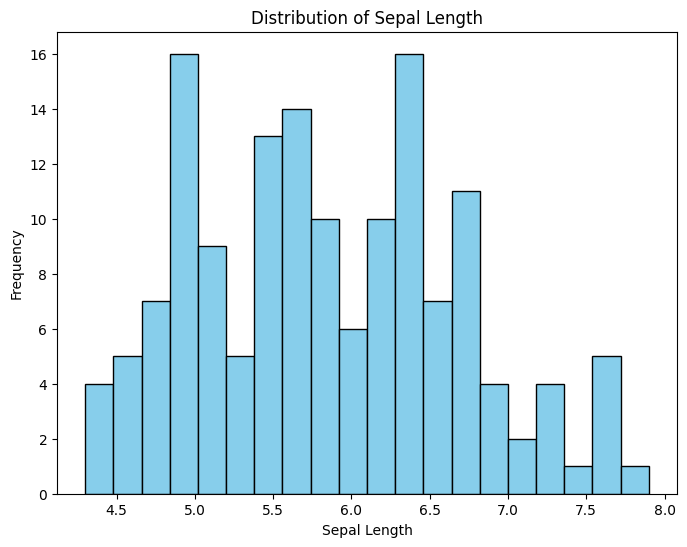

In [ ]:
# Plot histogram of 'sepal_length'
plt.figure(figsize=(8, 6))
plt.hist(iris['sepal_length'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Sepal Length')
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.show()

# 3. Create scatter plots to understand relationships between features
# Scatter plot for 'sepal_length' vs 'sepal_width'

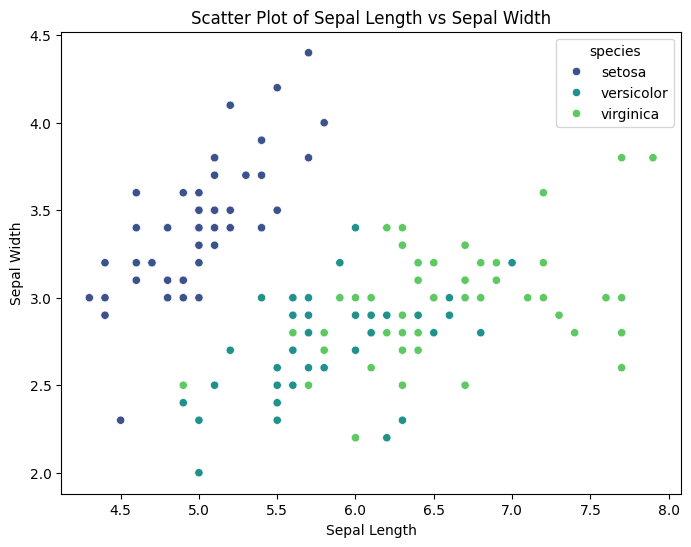

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=iris, palette='viridis')
plt.title('Scatter Plot of Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show()

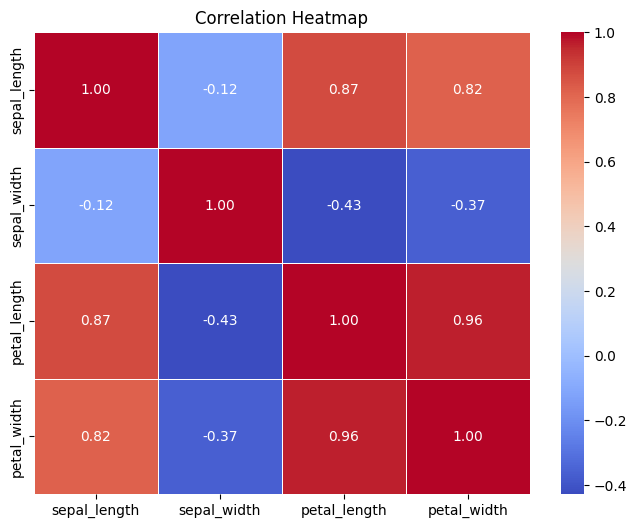

In [ ]:
# 4. Use a correlation heatmap to find relationships between multiple features

# Compute the correlation matrix
correlation_matrix = iris.drop(columns=['species']).corr()

# Plot the heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = sns.load_dataset("iris")

# ---- Missing Values ----
df.loc[0:3, "sepal_length"] = np.nan
df["sepal_length"].fillna(df["sepal_length"].mean(), inplace=True)

# ---- Encoding categorical data ----
label = LabelEncoder()
df["species"] = label.fit_transform(df["species"])

# ---- Feature Scaling ----
scaler = StandardScaler()
features = df.drop("species", axis=1).columns
df[features] = scaler.fit_transform(df[features])

print("Processed Dataset:")
print(df.head())


Processed Dataset:
   sepal_length  sepal_width  petal_length  petal_width  species
0      0.000000     1.019004     -1.340227    -1.315444        0
1      0.000000    -0.131979     -1.340227    -1.315444        0
2      0.000000     0.328414     -1.397064    -1.315444        0
3      0.000000     0.098217     -1.283389    -1.315444        0
4     -1.079198     1.249201     -1.340227    -1.315444        0


/tmp/ipython-input-533419460.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["sepal_length"].fillna(df["sepal_length"].mean(), inplace=True)


In [ ]:
import pandas as pd
import seaborn as sns

# Load Titanic dataset
df = sns.load_dataset("titanic")

print("Sample of Titanic Dataset:")
print(df.head())

Sample of Titanic Dataset:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


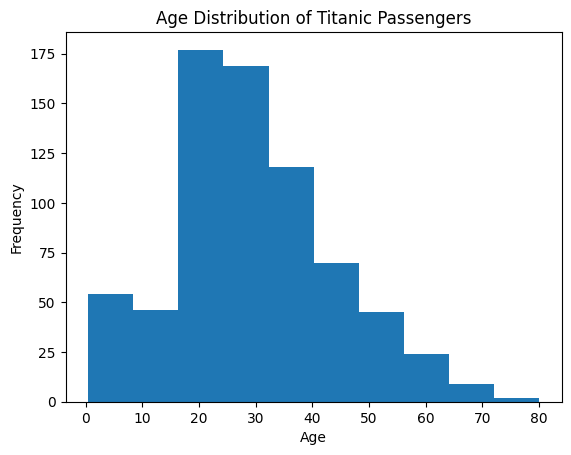

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("titanic")

plt.hist(df["age"].dropna())   # drop missing values to avoid warnings
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


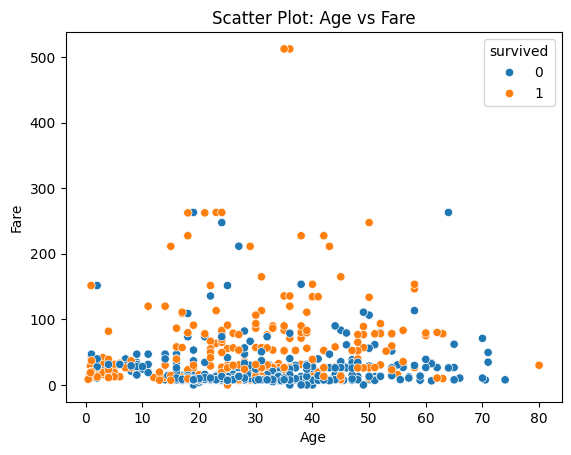

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

sns.scatterplot(x=df["age"], y=df["fare"], hue=df["survived"])
plt.title("Scatter Plot: Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


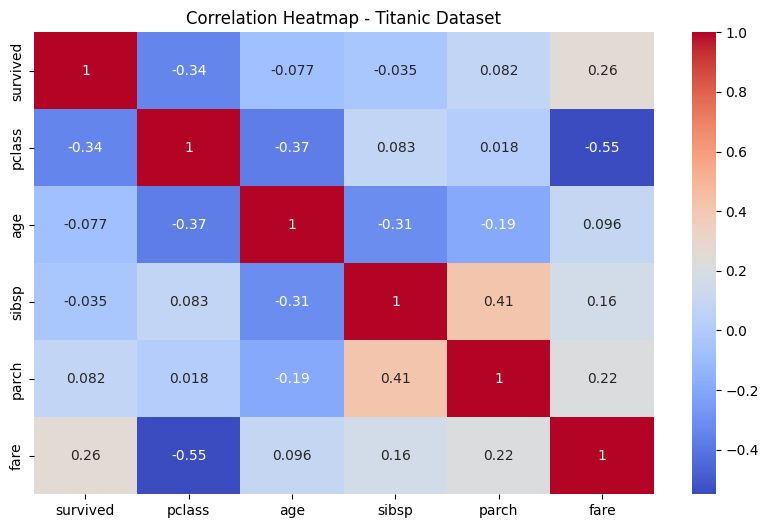

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

# Keep only numeric columns for correlation
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Titanic Dataset")
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = sns.load_dataset("titanic")

# ----- Handling Missing Values -----

# Fill numeric missing values with mean
df["age"] = df["age"].fillna(df["age"].mean())
df["fare"] = df["fare"].fillna(df["fare"].mean())

# Fill categorical missing values with mode (most common value)
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# ----- Encoding Categorical Variables -----

label = LabelEncoder()

categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    df[col] = label.fit_transform(df[col].astype(str))

# ----- Feature Scaling -----

scaler = StandardScaler()
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Processed Titanic Dataset:")
print(df.head())


Processed Titanic Dataset:
   survived    pclass       sex       age     sibsp     parch      fare  \
0 -0.789272  0.827377  0.737695 -0.592481  0.432793 -0.473674 -0.502445   
1  1.266990 -1.566107 -1.355574  0.638789  0.432793 -0.473674  0.786845   
2  1.266990  0.827377 -1.355574 -0.284663 -0.474545 -0.473674 -0.488854   
3  1.266990 -1.566107 -1.355574  0.407926  0.432793 -0.473674  0.420730   
4 -0.789272  0.827377  0.737695  0.407926 -0.474545 -0.473674 -0.486337   

   embarked     class       who  adult_male      deck  embark_town     alive  \
0  0.585954  0.827377 -0.355242        True  0.512048     0.581114 -0.789272   
1 -1.942303 -1.566107  1.328379       False -1.914733    -1.938460  1.266990   
2  0.585954  0.827377  1.328379       False  0.512048     0.581114  1.266990   
3  0.585954 -1.566107  1.328379       False -1.914733     0.581114  1.266990   
4  0.585954  0.827377 -0.355242        True  0.512048     0.581114 -0.789272   

   alone  
0  False  
1  False  
2   True

In [ ]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("planets")

print("Sample of Planets Dataset:")
print(df.head())


Sample of Planets Dataset:
            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1         269.300   7.10     77.40  2006
1  Radial Velocity       1         874.774   2.21     56.95  2008
2  Radial Velocity       1         763.000   2.60     19.84  2011
3  Radial Velocity       1         326.030  19.40    110.62  2007
4  Radial Velocity       1         516.220  10.50    119.47  2009


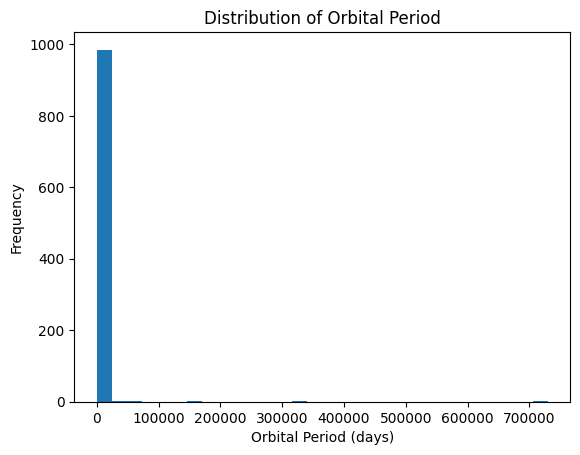

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("planets")

# Remove missing values for clean plotting
plt.hist(df["orbital_period"].dropna(), bins=30)
plt.title("Distribution of Orbital Period")
plt.xlabel("Orbital Period (days)")
plt.ylabel("Frequency")
plt.show()


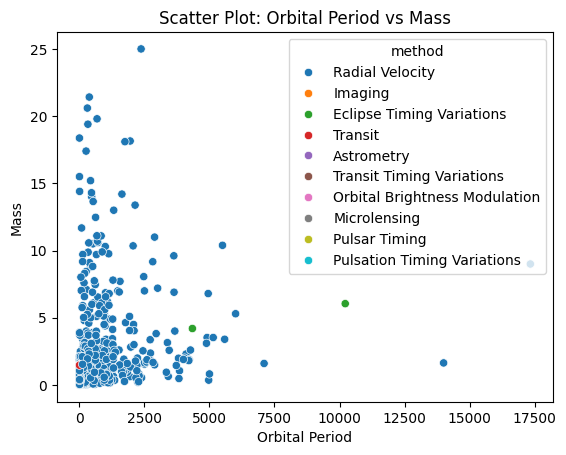

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("planets")

sns.scatterplot(x=df["orbital_period"], y=df["mass"], hue=df["method"])
plt.title("Scatter Plot: Orbital Period vs Mass")
plt.xlabel("Orbital Period")
plt.ylabel("Mass")
plt.show()


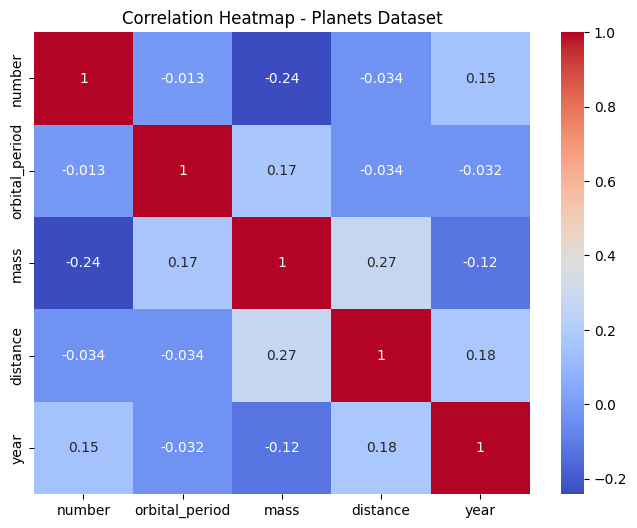

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("planets")

# Select only numeric columns
numeric_df = df.select_dtypes(include=["float64", "int64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Planets Dataset")
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = sns.load_dataset("planets")

# ----- Handling Missing Values -----

# Fill numeric missing values with mean
for col in df.select_dtypes(include=["float64", "int64"]).columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical missing values with mode
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# ----- Encoding Categorical Variables -----

label = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = label.fit_transform(df[col].astype(str))

# ----- Feature Scaling -----

scaler = StandardScaler()
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Processed Planets Dataset:")
print(df.head())


Processed Planets Dataset:
     method    number  orbital_period      mass  distance      year
0 -0.023196 -0.633281       -0.068103  1.661281 -0.288359 -0.773308
1 -0.023196 -0.633281       -0.044318 -0.159417 -0.319949 -0.269611
2 -0.023196 -0.633281       -0.048709 -0.014208 -0.377275  0.485933
3 -0.023196 -0.633281       -0.065875  6.240952 -0.237042 -0.521459
4 -0.023196 -0.633281       -0.058403  2.927206 -0.223371 -0.017763


In [ ]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("diamonds")

print("Sample of Diamonds Dataset:")
print(df.head())


Sample of Diamonds Dataset:
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


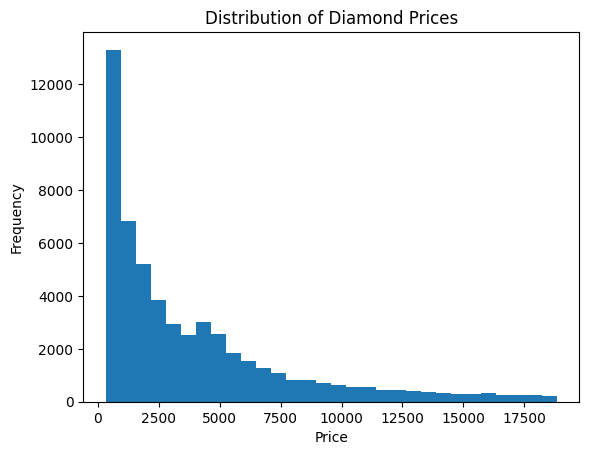

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("diamonds")

plt.hist(df["price"], bins=30)
plt.title("Distribution of Diamond Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


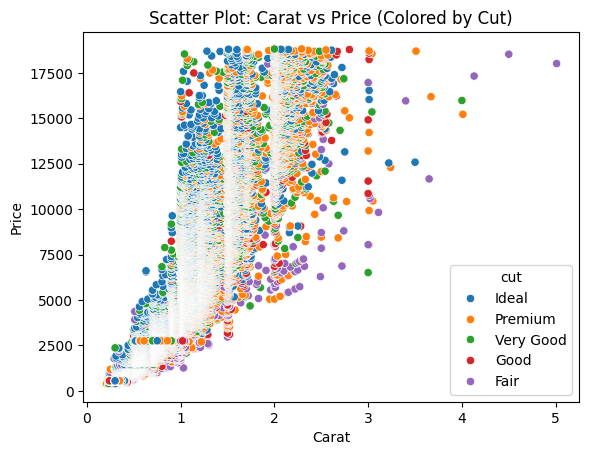

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("diamonds")

sns.scatterplot(x=df["carat"], y=df["price"], hue=df["cut"])
plt.title("Scatter Plot: Carat vs Price (Colored by Cut)")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.show()


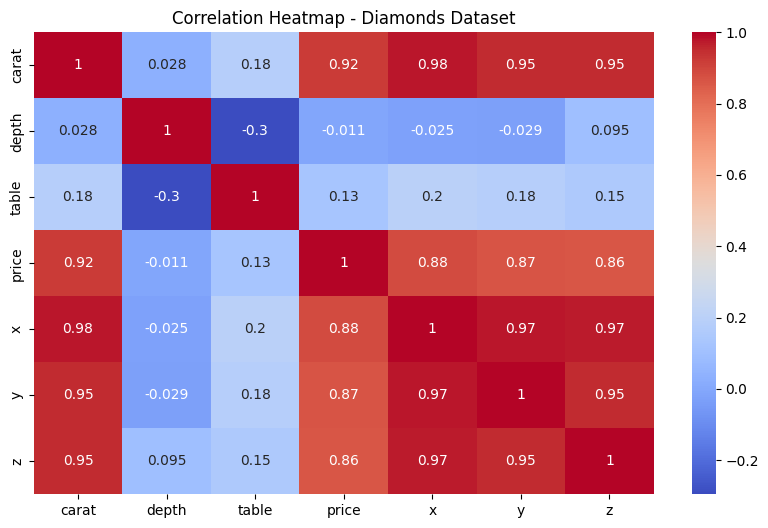

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("diamonds")

numeric_df = df.select_dtypes(include=["float64", "int64"])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Diamonds Dataset")
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = sns.load_dataset("diamonds")

# ----- Handling Missing Values -----
df = df.fillna(df.mean(numeric_only=True))

# ----- Encoding Categorical Columns -----
label = LabelEncoder()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    df[col] = label.fit_transform(df[col])

# ----- Feature Scaling -----
scaler = StandardScaler()
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Processed Diamonds Dataset:")
print(df.head())


Processed Diamonds Dataset:
      carat       cut     color   clarity     depth     table     price  \
0 -1.198168 -0.538099 -0.937163 -0.484264 -0.174092 -1.099672 -0.904095   
1 -1.240361  0.434949 -0.937163 -1.064117 -1.360738  1.585529 -0.904095   
2 -1.198168 -1.511147 -0.937163  0.095589 -3.385019  3.375663 -0.903844   
3 -1.071587  0.434949  1.414272  0.675442  0.454133  0.242928 -0.902090   
4 -1.029394 -1.511147  2.002131 -0.484264  1.082358  0.242928 -0.901839   

          x         y         z  
0 -1.587837 -1.536196 -1.571129  
1 -1.641325 -1.658774 -1.741175  
2 -1.498691 -1.457395 -1.741175  
3 -1.364971 -1.317305 -1.287720  
4 -1.240167 -1.212238 -1.117674  


In [ ]:
import math

# Given tuples
point1 = (22, 1, 42, 10)
point2 = (20, 2, 38, 8)

# Calculate Euclidean distance
distance = math.sqrt(
    (point2[0] - point1[0])**2 +
    (point2[1] - point1[1])**2 +
    (point2[2] - point1[2])**2 +
    (point2[3] - point1[3])**2
)

print("Euclidean Distance:", distance)


Euclidean Distance: 5.0


In [ ]:
data = {
    "Product": ["P1", "P1", "P2", "P2"],
    "Region":  ["North", "South", "North", "South"],
    "Q1":      [40, 30, 20, 10],
    "Q2":      [60, 50, 40, 30]
}
df = pd.DataFrame(data)
print("Original cube:")
print(df, "\n")

# a) Roll-up on Time dimension
# Total sales = Q1 + Q2 for each (Product, Region) pair
df_rollup = df.copy()
df_rollup["Total"] = df_rollup["Q1"] + df_rollup["Q2"]
df_rollup = df_rollup[["Product", "Region", "Total"]]

print("a) Roll-up on Time (Q1 + Q2) for each (Product, Region):")
print(df_rollup, "\n")

# b) Slice: Product = 'P1'
df_slice = df[df["Product"] == "P1"]

print("b) Slice (Product = 'P1') across Region and Time:")
print(df_slice, "\n")

# c) Dice: Region = 'North' AND Time = 'Q2'

df_dice = df[df["Region"] == "North"][["Product", "Region", "Q2"]]

print("c) Dice (Region = 'North' AND Time = 'Q2'):")
print(df_dice)

Original cube:
  Product Region  Q1  Q2
0      P1  North  40  60
1      P1  South  30  50
2      P2  North  20  40
3      P2  South  10  30 

a) Roll-up on Time (Q1 + Q2) for each (Product, Region):
  Product Region  Total
0      P1  North    100
1      P1  South     80
2      P2  North     60
3      P2  South     40 

b) Slice (Product = 'P1') across Region and Time:
  Product Region  Q1  Q2
0      P1  North  40  60
1      P1  South  30  50 

c) Dice (Region = 'North' AND Time = 'Q2'):
  Product Region  Q2
0      P1  North  60
2      P2  North  40


In [ ]:
y = [5, 6, 7, 8, 3]
y_pred = [5, 4, 7, 9, 2]

# Calculate MSE
mse = sum((yp - yt)**2 for yt, yp in zip(y, y_pred)) / len(y)

print("Mean Squared Error:", mse)


Mean Squared Error: 1.2


In [ ]:
import numpy as np

ages = np.array([23,23,52,54,54,56,57,58,58,60,61])
fat = np.array([9.5,26.5,34.6,42.5,28.8,33.4,30.2,34.1,32.9,41.2,35.7])

# Calculations
mean_age = np.mean(ages)
median_age = np.median(ages)
std_age = np.std(ages, ddof=1)

mean_fat = np.mean(fat)
median_fat = np.median(fat)
std_fat = np.std(fat, ddof=1)

# Correlation coefficient
corr = np.corrcoef(ages, fat)[0, 1]

print("Mean Age:", mean_age)
print("Median Age:", median_age)
print("Std Dev Age:", std_age)
print("Mean %Fat:", mean_fat)
print("Median %Fat:", median_fat)
print("Std Dev %Fat:", std_fat)
print("Correlation Coefficient:", corr)


Mean Age: 50.54545454545455
Median Age: 56.0
Std Dev Age: 13.873454049829382
Mean %Fat: 31.763636363636362
Median %Fat: 33.4
Std Dev %Fat: 8.785701193106073
Correlation Coefficient: 0.7747423970687436


Mean Squared Error: 3.4779242000519717
R2 Score: 0.9986088303199792


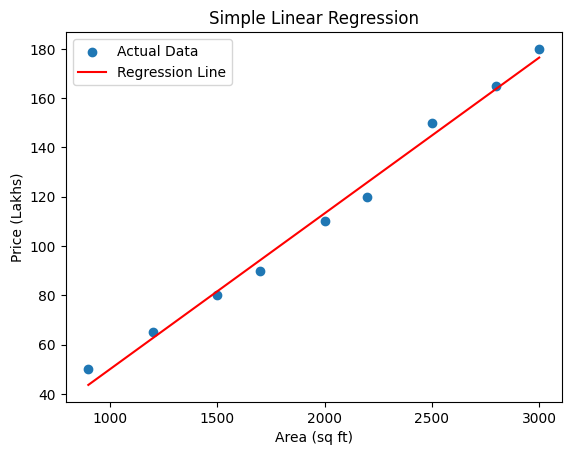

In [ ]:
# Simple Linear Regression to predict house prices

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Sample dataset (You can replace this with any real dataset)
data = {
    'Area': [900, 1200, 1500, 1700, 2000, 2200, 2500, 2800, 3000],
    'Price': [50, 65, 80, 90, 110, 120, 150, 165, 180]  # in lakhs
}

df = pd.DataFrame(data)

# Select feature and target
X = df[['Area']]
y = df['Price']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Plotting
plt.scatter(df['Area'], df['Price'], label="Actual Data")
plt.plot(df['Area'], model.predict(df[['Area']]), color='red', label="Regression Line")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (Lakhs)")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()


Mean Squared Error: 0.7091157771765549
R2 Score: 0.45885918903846656


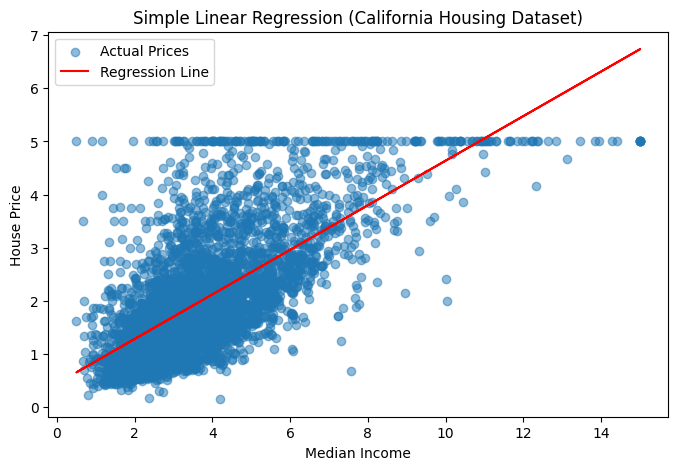

In [ ]:
# Simple Linear Regression using California Housing Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target  # price is the target

# We choose one feature (simple linear regression)
X = df[['MedInc']]   # Median Income
y = df['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Plot scatter + regression line
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, label="Actual Prices", alpha=0.5)
plt.plot(X_test, y_pred, color='red', label="Regression Line")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression (California Housing Dataset)")
plt.legend()
plt.show()


In [ ]:
import numpy as np
from statistics import mode

values = [0, 1, 2, 3, 4,5]
freq   = [27, 96, 58, 54, 18, 7]

# Expand into full dataset
data = []
for v, f in zip(values, freq):
    data.extend([v]*f)

# Mean
mean_val = sum(data) / len(data)

# Median
data_sorted = sorted(data)
n = len(data)
if n % 2 == 1:
    median_val = data_sorted[n//2]
else:
    median_val = (data_sorted[n//2 - 1] + data_sorted[n//2]) / 2

# Mode
from collections import Counter
mode_val = Counter(data).most_common(1)[0][0]

mean_val, median_val, mode_val


(1.85, 2.0, 1)

In [ ]:
freq = [5, 3, 15, 40, 17, 12, 7, 1]

# Q2(a)
less_than_65_95 = sum(freq[0:3])
percent_a = less_than_65_95

# Q2(b)
between_61_95_65_95 = sum(freq[1:3])
percent_b = between_61_95_65_95

# Q2(c)
between_61_95_71_95 = sum(freq[1:3])
players_c = between_61_95_71_95

percent_a, percent_b, players_c


(23, 18, 18)

In [ ]:
import numpy as np

data = np.array([46, 49, 32, 60, 52, 41])

# Mean
mean_val = np.mean(data)

# Deviations from mean
deviations = data - mean_val

# Squared deviations
sq_dev = deviations**2

# Sample variance (n-1)
variance_sample = sq_dev.sum() / (len(data) - 1)

# Population variance (n)
variance_population = sq_dev.sum() / len(data)

# Standard deviation
std_sample = variance_sample**0.5
std_population = variance_population**0.5

mean_val, variance_population, variance_sample, std_population, std_sample


(np.float64(46.666666666666664),
 np.float64(76.55555555555554),
 np.float64(91.86666666666665),
 np.float64(8.749603165604457),
 np.float64(9.58471004604034))

In [ ]:
import numpy as np
import scipy.stats as stats

# Grouped data
midpoints = np.array([3, 5, 7, 9])
frequencies = np.array([3, 4, 2, 1])

# Expand data: repeat midpoints according to frequency
data = np.repeat(midpoints, frequencies)

# Mean
mean_value = np.mean(data)

# Standard deviation (sample)
std_dev = np.std(data, ddof=1)

# Sample skewness
skewness = stats.skew(data, bias=False)

# Sample kurtosis (excess kurtosis -> +3 to get classical kurtosis)
kurtosis_excess = stats.kurtosis(data, bias=False)
kurtosis = kurtosis_excess + 3

print("Mean =", mean_value)
print("Sample Standard Deviation =", std_dev)
print("Sample Skewness =", skewness)
print("Sample Kurtosis =", kurtosis)


Mean = 5.2
Sample Standard Deviation = 1.9888578520235065
Sample Skewness = 0.6101407120839688
Sample Kurtosis = 2.8425523472865986


In [ ]:
import numpy as np
import pandas as pd

# Example dataset (you will replace these with actual values if needed)
# Enter the values for each characteristic
systolic = np.array([120, 130, 110, 140, 125, 123, 121, 119, 132, 128])
diastolic = np.array([80, 85, 78, 90, 88, 82, 87, 77, 84, 86])
cholesterol = np.array([200, 190, 195, 210, 220, 205, 198, 202, 215, 185])

# Put data into a dictionary
data = {
    "Systolic Blood Pressure": systolic,
    "Diastolic Blood Pressure": diastolic,
    "Cholesterol": cholesterol
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Function to compute summary stats
def summary_stats(column):
    values = df[column]
    mean = np.mean(values)
    sd = np.std(values, ddof=1)
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1
    return mean, sd, median, q1, q3, iqr

# Compute for all columns
summary = {}
for col in df.columns:
    summary[col] = summary_stats(col)

summary


{'Systolic Blood Pressure': (np.float64(124.8),
  8.256983576208553,
  np.float64(124.0),
  np.float64(120.25),
  np.float64(129.5),
  np.float64(9.25)),
 'Diastolic Blood Pressure': (np.float64(83.7),
  4.347413023856832,
  np.float64(84.5),
  np.float64(80.5),
  np.float64(86.75),
  np.float64(6.25)),
 'Cholesterol': (np.float64(202.0),
  10.893423092245461,
  np.float64(201.0),
  np.float64(195.75),
  np.float64(208.75),
  np.float64(13.0))}

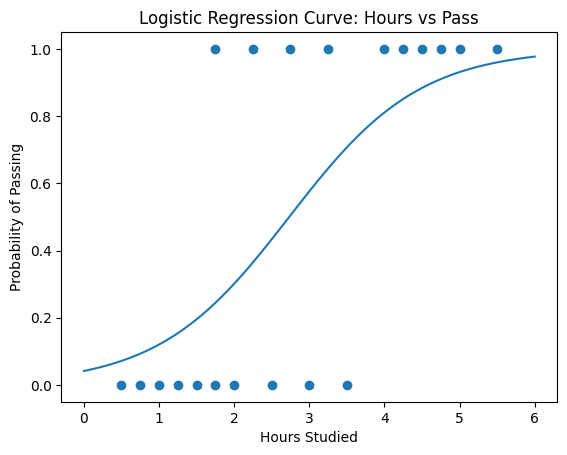

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Given data
hours = np.array([
    0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25,
    2.50, 2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75,
    5.00, 5.50
]).reshape(-1, 1)

pass_fail = np.array([
    0, 0, 0, 0, 0, 0, 1, 0, 1,
    0, 1, 0, 1, 0, 1, 1, 1, 1,
    1, 1
])

# Logistic Regression model
model = LogisticRegression()
model.fit(hours, pass_fail)

# Generate smooth curve
x_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_prob = model.predict_proba(x_test)[:, 1]

# Plot
plt.scatter(hours, pass_fail)
plt.plot(x_test, y_prob)
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression Curve: Hours vs Pass")
plt.show()


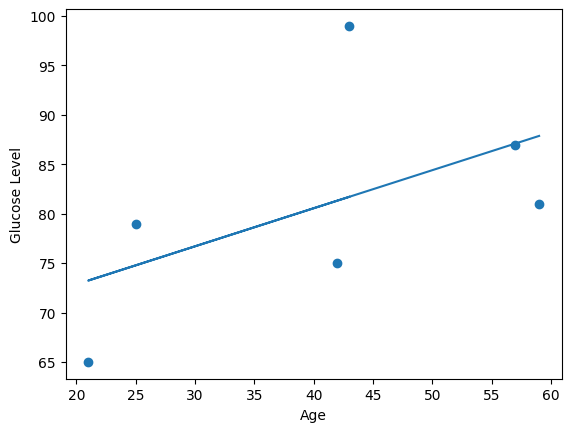

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

age = np.array([43, 21, 25, 42, 57, 59]).reshape(-1, 1)
glucose = np.array([99, 65, 79, 75, 87, 81])

model = LinearRegression()
model.fit(age, glucose)

predicted = model.predict(age)

plt.scatter(age, glucose)
plt.plot(age, predicted)
plt.xlabel("Age")
plt.ylabel("Glucose Level")
plt.show()


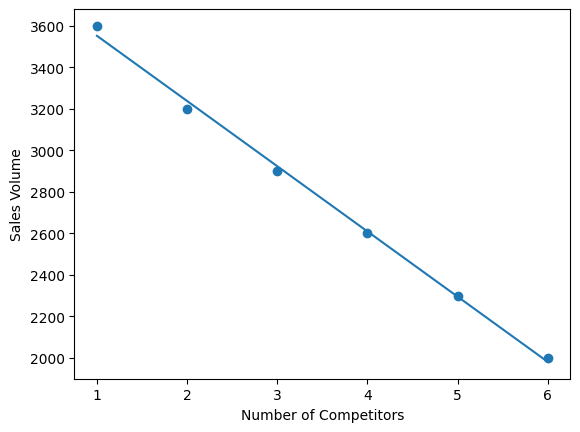

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

competitors = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
sales = np.array([3600, 3200, 2900, 2600, 2300, 2000])

model = LinearRegression()
model.fit(competitors, sales)

predicted_sales = model.predict(competitors)

plt.scatter(competitors, sales)
plt.plot(competitors, predicted_sales)
plt.xlabel("Number of Competitors")
plt.ylabel("Sales Volume")
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

actual = np.array([112, 115, ])
predicted = np.array([113, 112, 116, 117, 110, 118, 121, 115])

mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)

hybrid_error = 0.3 * mse + 0.25 * rmse

mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print("MSE:", mse)
print("RMSE:", rmse)
print("Hybrid Error:", hybrid_error)
print("MAPE:", mape)


MSE: 3.125
RMSE: 1.7677669529663689
Hybrid Error: 1.3794417382415922
MAPE: 1.4041559421321994


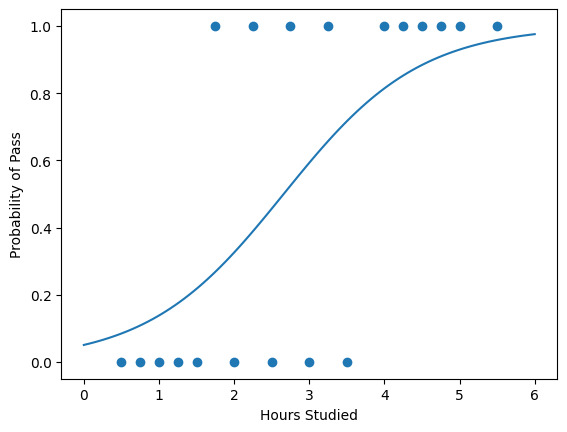

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

hours = np.array([0.5,0.75,1,1.25,1.5,1.75,2,2.25,2.5,2.75,
                  3,3.25,3.5,4,4.25,4.5,4.75,5,5.5]).reshape(-1,1)

pass_fail = np.array([0,0,0,0,0,1,0,1,0,1,0,1,0,1,1,1,1,1,1])

model = LogisticRegression()
model.fit(hours, pass_fail)

x_test = np.linspace(0, 6, 100).reshape(-1,1)
y_prob = model.predict_proba(x_test)[:,1]

plt.scatter(hours, pass_fail)
plt.plot(x_test, y_prob)
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Pass")
plt.show()


In [ ]:
# =============================
# Import Libraries
# =============================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# =============================
# Load MNIST Dataset
# =============================

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)

X = mnist.data
y = mnist.target

# Convert labels to integer
y = y.astype(int)

print("Data shape :", X.shape)
print("Labels shape :", y.shape)


Data shape : (70000, 784)
Labels shape : (70000,)
